In [1]:
import pandas as pd

In [134]:
# Работа с датой
# to_datetime
# set_index, DatetimeIndex
# Срезы loc
# Извлечение компонентов даты
# resample
# plot
# rolling
# shift, diff

# Задача:
# Скачать датасет с датой
# Создать DatetimeIndex
# Показть работу среза через loc
# Сделать график сравнение с обычными данными и resample, rolling

In [3]:
df = pd.read_csv('../data/raw/nvidia/nvidia_daily.csv')

In [4]:
df

,time,open,high,low,close,Plot,Plot.1,Plot.2,Plot.3
0,2022-02-03,24.458,25.077,23.780,23.948,NaN,NaN,NaN,NaN
1,2022-02-04,23.972,24.635,23.632,24.319,NaN,NaN,NaN,NaN
2,2022-02-07,24.372,25.182,24.202,24.728,NaN,NaN,NaN,NaN
3,2022-02-08,24.359,25.230,23.980,25.108,NaN,NaN,NaN,NaN
4,2022-02-09,25.622,26.725,25.353,26.705,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
917,2025-10-01,185.240,188.140,183.900,187.240,NaN,NaN,NaN,NaN
918,2025-10-02,189.600,191.050,188.060,188.890,NaN,NaN,NaN,NaN
919,2025-10-03,189.190,190.360,185.380,187.620,NaN,NaN,NaN,NaN
920,2025-10-06,185.500,187.230,183.330,185.540,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 922 entries, 0 to 921
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    922 non-null    object 
 1   open    922 non-null    float64
 2   high    922 non-null    float64
 3   low     922 non-null    float64
 4   close   922 non-null    float64
 5   Plot    0 non-null      float64
 6   Plot.1  0 non-null      float64
 7   Plot.2  0 non-null      float64
 8   Plot.3  0 non-null      float64
dtypes: float64(8), object(1)
memory usage: 65.0+ KB


In [6]:
df = df.drop(columns=['Plot', 'Plot.1', 'Plot.2', 'Plot.3'])

In [10]:
df['time'] = pd.to_datetime(df['time'])

In [11]:
df

,time,open,high,low,close
0,2022-02-03,24.458,25.077,23.780,23.948
1,2022-02-04,23.972,24.635,23.632,24.319
2,2022-02-07,24.372,25.182,24.202,24.728
3,2022-02-08,24.359,25.230,23.980,25.108
4,2022-02-09,25.622,26.725,25.353,26.705
...,...,...,...,...,...
917,2025-10-01,185.240,188.140,183.900,187.240
918,2025-10-02,189.600,191.050,188.060,188.890
919,2025-10-03,189.190,190.360,185.380,187.620
920,2025-10-06,185.500,187.230,183.330,185.540


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 922 entries, 0 to 921
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    922 non-null    datetime64[ns]
 1   open    922 non-null    float64       
 2   high    922 non-null    float64       
 3   low     922 non-null    float64       
 4   close   922 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 36.1 KB


In [15]:
df = df.set_index('time')

In [18]:
df

,open,high,low,close
time,,,,
2022-02-03,24.458,25.077,23.780,23.948
2022-02-04,23.972,24.635,23.632,24.319
2022-02-07,24.372,25.182,24.202,24.728
2022-02-08,24.359,25.230,23.980,25.108
2022-02-09,25.622,26.725,25.353,26.705
...,...,...,...,...
2025-10-01,185.240,188.140,183.900,187.240
2025-10-02,189.600,191.050,188.060,188.890
2025-10-03,189.190,190.360,185.380,187.620


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 922 entries, 2022-02-03 to 2025-10-07
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    922 non-null    float64
 1   high    922 non-null    float64
 2   low     922 non-null    float64
 3   close   922 non-null    float64
dtypes: float64(4)
memory usage: 36.0 KB


In [22]:
df[df.index=='2022-02-03']

,open,high,low,close
time,,,,
2022-02-03,24.458,25.077,23.78,23.948


In [23]:
df[(df.index >= '2025-01-01') & (df.index < '2026-01-01')]

,open,high,low,close
time,,,,
2025-01-02,136.00,138.880,134.6300,138.31
2025-01-03,140.01,144.900,139.7300,144.47
2025-01-06,148.59,152.156,147.8201,149.43
2025-01-07,153.03,153.130,140.0100,140.14
2025-01-08,142.58,143.950,137.5600,140.11
...,...,...,...,...
2025-10-01,185.24,188.140,183.9000,187.24
2025-10-02,189.60,191.050,188.0600,188.89
2025-10-03,189.19,190.360,185.3800,187.62


In [25]:
df.loc[['2022-02-03']]

,open,high,low,close
time,,,,
2022-02-03,24.458,25.077,23.78,23.948


In [33]:
df.loc['2023':'2025']

,open,high,low,close
time,,,,
2023-01-03,14.851,14.996,14.09600,14.315
2023-01-04,14.567,14.853,14.24100,14.749
2023-01-05,14.491,14.564,14.14795,14.265
2023-01-06,14.474,15.010,14.03400,14.859
2023-01-09,15.284,16.056,15.14100,15.628
...,...,...,...,...
2025-10-01,185.240,188.140,183.90000,187.240
2025-10-02,189.600,191.050,188.06000,188.890
2025-10-03,189.190,190.360,185.38000,187.620


In [36]:
df.loc['2025-01':'2025-06']

,open,high,low,close
time,,,,
2025-01-02,136.000,138.880,134.6300,138.31
2025-01-03,140.010,144.900,139.7300,144.47
2025-01-06,148.590,152.156,147.8201,149.43
2025-01-07,153.030,153.130,140.0100,140.14
2025-01-08,142.580,143.950,137.5600,140.11
...,...,...,...,...
2025-06-24,145.560,147.960,145.5000,147.90
2025-06-25,149.270,154.450,149.2600,154.31
2025-06-26,155.975,156.715,154.0000,155.02


In [46]:
df['year'] = df.index.year
df['month'] = df.index.month
df['dayofweek'] = df.index.dayofweek
df['day_name'] = df.index.day_name()
df['quarter'] = df.index.quarter

In [53]:
df.groupby(by=['year', 'quarter'])['close'].median()

year  quarter
2022  1           24.3520
      2           18.4810
      3           15.8195
      4           14.6140
2023  1           22.1890
      2           29.6955
      3           44.6800
      4           46.7650
2024  1           72.1330
      2           92.1400
      3          118.5900
      4          138.4400
2025  1          125.7750
      2          131.5450
      3          175.9400
      4          187.2400
Name: close, dtype: float64

In [66]:
df['close'].resample('MS').median()

time
2022-02-01     24.3190
2022-03-01     24.4960
2022-04-01     21.6435
2022-05-01     17.5950
2022-06-01     16.5660
2022-07-01     15.9795
2022-08-01     17.9420
2022-09-01     13.1760
2022-10-01     12.4660
2022-11-01     15.6770
2022-12-01     16.5010
2023-01-01     17.1380
2023-02-01     22.0020
2023-03-01     25.5410
2023-04-01     27.1040
2023-05-01     29.1820
2023-06-01     41.0220
2023-07-01     45.4605
2023-08-01     44.6800
2023-09-01     43.9330
2023-10-01     43.8005
2023-11-01     48.1400
2023-12-01     48.2305
2024-01-01     56.3820
2024-02-01     72.1905
2024-03-01     89.8240
2024-04-01     86.7205
2024-05-01     93.4190
2024-06-01    123.9900
2024-07-01    123.1050
2024-08-01    118.7250
2024-09-01    116.5200
2024-10-01    135.7200
2024-11-01    143.6200
2024-12-01    137.4900
2025-01-01    136.9750
2025-02-01    131.1400
2025-03-01    115.5800
2025-04-01    107.5700
2025-05-01    131.8000
2025-06-01    144.0400
2025-07-01    170.7400
2025-08-01    180.1700
2025-0

<Axes: xlabel='time'>

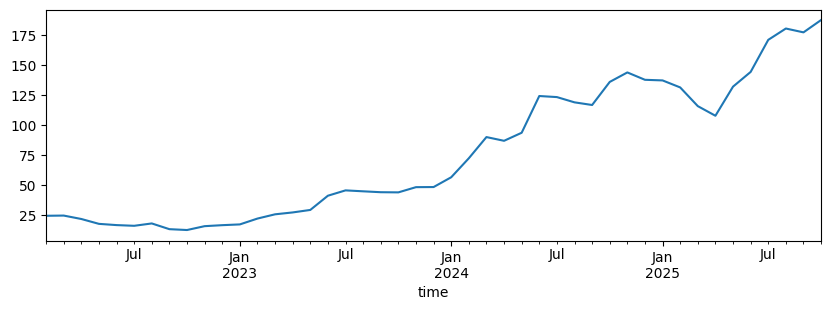

In [70]:
df['close'].resample('MS').median().plot(figsize=(10,3))

<Axes: xlabel='time'>

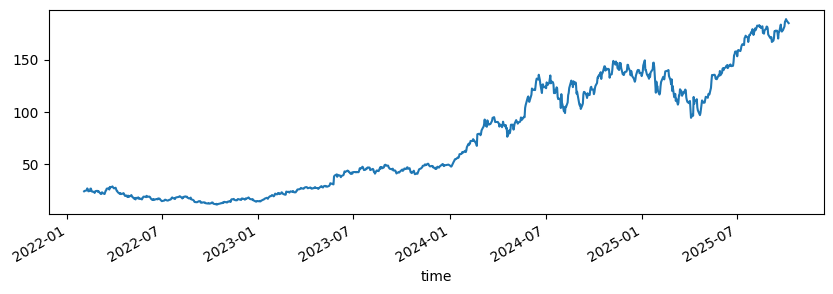

In [71]:
df['close'].plot(figsize=(10,3))

<Axes: xlabel='time'>

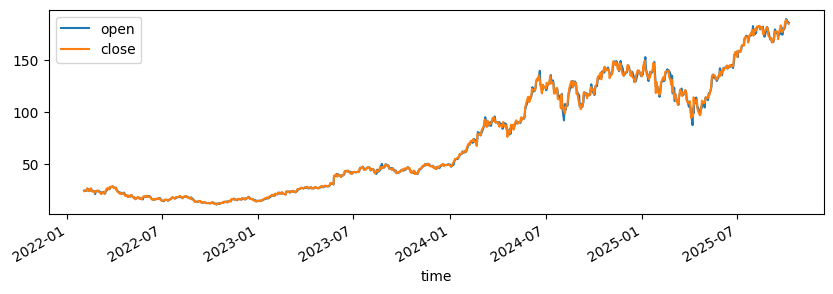

In [77]:
df[['open', 'close']].plot(figsize=(10,3))

<Axes: xlabel='time'>

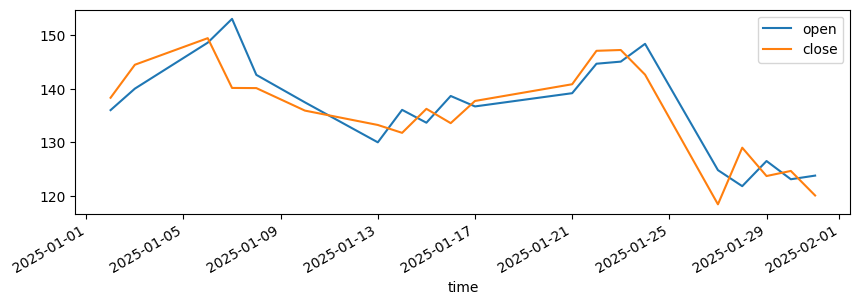

In [76]:
df[['open', 'close']].loc['2025-01'].plot(figsize=(10,3))

In [105]:
df['close_rolling_mean'] = df['close'].rolling(window=7, min_periods=1).mean()

In [99]:
df.loc['2022-02'][['close', 'close_rolling_mean']]

,close,close_rolling_mean
time,,
2022-02-03,23.948,23.948000
2022-02-04,24.319,24.133500
2022-02-07,24.728,24.331667
2022-02-08,25.108,24.525750
2022-02-09,26.705,24.961600
2022-02-10,25.824,25.105333
2022-02-11,23.949,24.940143
2022-02-14,24.267,24.985714
2022-02-15,26.495,25.296571


<Axes: xlabel='time'>

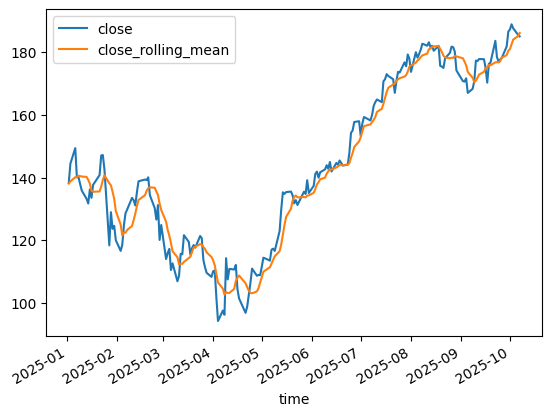

In [106]:
df[['close', 'close_rolling_mean']].loc['2025'].plot()

In [109]:
df['close_diff'] = df['close'].diff()

In [123]:
df['close_prev_week'] = df['close'].shift(7)

In [126]:
df[['close', 'close_prev_week']].loc['2022-02']

,close,close_prev_week
time,,
2022-02-03,23.948,NaN
2022-02-04,24.319,NaN
2022-02-07,24.728,NaN
2022-02-08,25.108,NaN
2022-02-09,26.705,NaN
2022-02-10,25.824,NaN
2022-02-11,23.949,NaN
2022-02-14,24.267,23.948
2022-02-15,26.495,24.319


In [127]:
df_1 = pd.read_csv('../data/raw/pop.csv')

In [131]:
df_1['1800_prev'] = df_1['1800'].shift(1)

In [132]:
df_1

,country,1800,1801,1802,1803,1804,1805,1806,1807,1808,...,2092,2093,2094,2095,2096,2097,2098,2099,2100,1800_prev
0,Afghanistan,3.28M,3.28M,3.28M,3.28M,3.28M,3.28M,3.28M,3.28M,3.28M,...,125M,126M,126M,127M,128M,128M,129M,130M,130M,None
1,Angola,1.57M,1.57M,1.57M,1.57M,1.57M,1.57M,1.57M,1.57M,1.57M,...,140M,142M,143M,144M,145M,147M,148M,149M,150M,3.28M
2,Albania,400k,402k,404k,405k,407k,409k,411k,413k,414k,...,1.32M,1.3M,1.29M,1.27M,1.25M,1.23M,1.22M,1.2M,1.18M,1.57M
3,Andorra,2650,2650,2650,2650,2650,2650,2650,2650,2650,...,52.1k,51.5k,50.8k,50.2k,49.6k,49k,48.4k,47.8k,47.2k,400k
4,UAE,40.2k,40.2k,40.2k,40.2k,40.2k,40.2k,40.2k,40.2k,40.2k,...,24.3M,24.5M,24.7M,25M,25.2M,25.4M,25.7M,25.9M,26.1M,2650
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,Samoa,47.3k,47.3k,47.3k,47.3k,47.3k,47.3k,47.3k,47.2k,47.2k,...,372k,374k,375k,377k,378k,380k,381k,382k,384k,27.8k
193,Yemen,2.59M,2.59M,2.59M,2.59M,2.59M,2.59M,2.59M,2.59M,2.59M,...,107M,107M,108M,108M,109M,109M,109M,110M,110M,47.3k
194,South Africa,1.45M,1.45M,1.46M,1.46M,1.47M,1.47M,1.48M,1.49M,1.49M,...,92.6M,92.9M,93.1M,93.3M,93.5M,93.7M,93.9M,94.1M,94.3M,2.59M
195,Zambia,747k,758k,770k,782k,794k,806k,818k,831k,843k,...,61.5M,61.9M,62.3M,62.7M,63.1M,63.4M,63.8M,64.1M,64.5M,1.45M
